In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import normflows as nf

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def make_regression_data(n=200, p=100, sigma2=0.5, beta_signal=None, device="cpu"):
    if beta_signal is None:
        beta_signal = [1.5, -0.8, 0.7, -1.2, 0.5]

    beta_signal = torch.as_tensor(beta_signal, dtype=torch.float32, device=device)
    k = len(beta_signal)

    if k > p:
        raise ValueError("len(beta_signal) cannot exceed p")

    # X_ij ~ N(0,1)
    X = torch.randn(n, p, device=device)

    # beta_true = (beta_signal_1, ..., beta_signal_k, 0, ..., 0)
    beta_true = torch.zeros(p, device=device)
    beta_true[:k] = beta_signal

    # eps ~ N(0, sigma2 I_n)
    eps = math.sqrt(sigma2) * torch.randn(n, device=device)

    # y = X beta_true + eps
    y = X @ beta_true + eps

    return X, y, beta_true

In [3]:
def gaussian_posterior_closed_form(X, y, sigma2, Sigma):
    
    # Prior precision matrix: Sigma^{-1}
    Sigma_inv = torch.linalg.inv(Sigma)

    # Posterior covariance:
    #   Sigma_post = [ (X^T X)/sigma2 + Sigma^{-1} ]^{-1}
    Sigma_post = torch.linalg.inv((X.T @ X) / sigma2 + Sigma_inv)

    # Posterior mean:
    #   mu_post = Sigma_post (X^T y)/sigma2
    mu_post = Sigma_post @ (X.T @ y) / sigma2

    return mu_post, Sigma_post


def summarize_beta_samples(beta_samples):
    
    # Empirical posterior mean:
    #   beta_mean_hat = (1/m) sum_i beta^(i)
    beta_mean_hat = beta_samples.mean(dim=0)

    # Center each sample:
    #   beta_centered^(i) = beta^(i) - beta_mean_hat
    beta_centered = beta_samples - beta_mean_hat

    # Empirical posterior covariance:
    #   beta_cov_hat = (1/(m-1)) * centered^T centered
    beta_cov_hat = beta_centered.T @ beta_centered / (beta_samples.shape[0] - 1)

    return beta_mean_hat, beta_cov_hat

In [4]:
class RelaxedSpikeSlabTarget(nn.Module):
    """
    Relaxed spike-and-slab target distribution for Bayesian linear regression.

    Unified latent-variable formulation
    ----------------------------------
    For j = 1, ..., p, define

        g_j^(tau) = sigmoid((u_j - t) / tau),
        beta_j    = s_j * g_j^(tau),

    where

        s_j : slab amplitude
        u_j : latent gate variable
        t   : global threshold
        tau : temperature parameter

    Observation model
    -----------------
        y | X, beta, sigma2 ~ N(X beta, sigma2 * I_n)

    Priors
    ------
        s_j ~ Laplace(0, 1/lambda_s)     if slab == "laplace"
        s_j ~ N(0, slab_scale^2)         if slab == "gaussian"

        u_j ~ N(0, 1)
        t   ~ N(mu_t, sigma_t^2)

    Notes
    -----
    This class defines an unnormalized log posterior in the latent space

        z = (s_1,...,s_p, u_1,...,u_p, t) in R^(2p+1).

    The hard-thresholding interpretation is recovered in post-processing:
        g_j^(tau) > 0.5  <=>  u_j > t
    so threshold=0.5 is exactly aligned with the original hard gate I(u_j > t).
    """

    def __init__(
        self,
        X,
        y,
        sigma2,
        lambda_s=1.0,
        mu_t=0.0,
        sigma_t=1.0,
        tau=0.5,
        slab="laplace",   # "laplace" or "gaussian"
        slab_scale=1.0,   # only used when slab == "gaussian"
    ):
        super().__init__()
        # ---------------------------------------------------------
        # Fixed data and likelihood variance
        #
        #   y | X, beta ~ N(X beta, sigma2 I_n)
        # ---------------------------------------------------------
        self.register_buffer("X", X)
        self.register_buffer("y", y)
        self.register_buffer(
            "sigma2",
            torch.as_tensor(float(sigma2), dtype=X.dtype, device=X.device)
        )

        # Number of regression coefficients
        self.p = X.shape[1]

        # Slab family: either "laplace" or "gaussian"
        self.slab = slab

        # ---------------------------------------------------------
        # Prior / relaxation hyperparameters
        #
        # If slab == "laplace":
        #   s_j ~ Laplace(0, 1/lambda_s)
        #
        # If slab == "gaussian":
        #   s_j ~ N(0, slab_scale^2)
        #
        # Gate variable:
        #   u_j ~ N(0,1)
        #
        # Threshold:
        #   t ~ N(mu_t, sigma_t^2)
        #
        # Relaxed gate:
        #   g_j^(tau) = sigmoid((u_j - t) / tau)
        # ---------------------------------------------------------
        self.register_buffer(
            "lambda_s",
            torch.as_tensor(float(lambda_s), dtype=X.dtype, device=X.device)
        )
        self.register_buffer(
            "mu_t",
            torch.as_tensor(float(mu_t), dtype=X.dtype, device=X.device)
        )
        self.register_buffer(
            "sigma_t",
            torch.as_tensor(float(sigma_t), dtype=X.dtype, device=X.device)
        )
        self.register_buffer(
            "tau",
            torch.as_tensor(float(tau), dtype=X.dtype, device=X.device)
        )
        self.register_buffer(
            "slab_scale",
            torch.as_tensor(float(slab_scale), dtype=X.dtype, device=X.device)
        )

    @property
    def latent_dim(self):
        """
        Dimension of latent variable z.

        Since
            z = (s_1,...,s_p, u_1,...,u_p, t),
        we have
            dim(z) = p + p + 1 = 2p + 1.
        """
        return 2 * self.p + 1

    def set_tau(self, tau):
        """
        Update the temperature parameter tau in place.

        This is useful for temperature annealing:
        start with a smoother gate (larger tau),
        then gradually reduce tau so that the gate becomes more
        similar to a hard threshold.
        """
        self.tau.fill_(float(tau))

    def split_latent(self, z):
        """
        Split latent samples z into (s, u, t).

        Parameters
        ----------
        z : torch.Tensor, shape [m, 2p+1]

        Returns
        -------
        s : torch.Tensor, shape [m, p]
            Slab amplitudes.
        u : torch.Tensor, shape [m, p]
            Latent gate variables.
        t : torch.Tensor, shape [m, 1]
            Global threshold.

        Latent structure
        ----------------
            z = (s_1,...,s_p, u_1,...,u_p, t)
        """
        s = z[:, :self.p]
        u = z[:, self.p: 2 * self.p]
        t = z[:, 2 * self.p: 2 * self.p + 1]
        return s, u, t

    def gate(self, u, t):
        """
        Compute the relaxed (soft) gate

            g_j^(tau) = sigmoid((u_j - t) / tau).

        Parameters
        ----------
        u : torch.Tensor, shape [m, p]
        t : torch.Tensor, shape [m, 1]

        Returns
        -------
        g : torch.Tensor, shape [m, p]

        Interpretation
        --------------
        - if u_j >> t, then g_j ≈ 1
        - if u_j << t, then g_j ≈ 0
        - if u_j ≈ t, then g_j is between 0 and 1
        """
        return torch.sigmoid((u - t) / self.tau)

    def beta_from_latent(self, z):
        """
        Construct regression coefficients beta from latent variable z.

        Formula
        -------
            beta_j = s_j * g_j^(tau),
            g_j^(tau) = sigmoid((u_j - t) / tau)
        """
        if z.dim() == 1:
            z = z.unsqueeze(0)
        s, u, t = self.split_latent(z)
        g = self.gate(u, t)
        beta = s * g
        return beta

    def gate_from_latent(self, z):
        """
        Return soft gate values g^(tau) from latent variable z.
        """
        if z.dim() == 1:
            z = z.unsqueeze(0)
        _, u, t = self.split_latent(z)
        return self.gate(u, t)

    def hard_gate_from_latent(self, z, threshold=0.5):
        """
        Post-hoc hard thresholding of the soft gate.

        Default threshold=0.5 is not arbitrary:
            g_j^(tau) > 0.5  <=>  u_j > t

        so this exactly recovers the original hard gate interpretation.
        """
        g = self.gate_from_latent(z)
        return (g > threshold).float()

    def hard_beta_from_latent(self, z, threshold=0.5):
        """
        Construct hard-thresholded regression coefficients.

        Formula
        -------
            beta_j^hard = s_j * I(g_j^(tau) > threshold)

        With threshold=0.5, this becomes equivalent to
            beta_j^hard = s_j * I(u_j > t).
        """
        if z.dim() == 1:
            z = z.unsqueeze(0)
        s, _, _ = self.split_latent(z)
        hard_g = self.hard_gate_from_latent(z, threshold=threshold)
        return s * hard_g

    def log_prob(self, z):
        """
        Unnormalized log posterior in latent space.

        Target
        ------
        For latent variable z = (s, u, t), define beta = beta(s,u,t).
        Then this function returns

            log p(y | X, beta, sigma2)
            + log p(s)
            + log p(u)
            + log p(t)

        up to an additive constant.

        Explicitly,
            log p(s,u,t | y,X)
            = log p(y | X, beta(s,u,t), sigma2)
              + log p(s) + log p(u) + log p(t) + C
        """
        if z.dim() == 1:
            z = z.unsqueeze(0)

        s, u, t = self.split_latent(z)
        beta = self.beta_from_latent(z)

        # ---------------------------------------------------------
        # Likelihood:
        #
        #   y | X, beta, sigma2 ~ N(X beta, sigma2 I_n)
        #
        # Ignoring constants,
        #
        #   log p(y | X, beta, sigma2)
        #   = -(1 / (2 sigma2)) * || y - X beta ||^2 + C
        # ---------------------------------------------------------
        mean = beta @ self.X.T
        resid = self.y.unsqueeze(0) - mean
        log_lik = -0.5 / self.sigma2 * (resid ** 2).sum(dim=1)

        # ---------------------------------------------------------
        # Prior on s:
        #
        # If slab == "laplace":
        #   s_j ~ Laplace(0, 1/lambda_s)
        #
        # If slab == "gaussian":
        #   s_j ~ N(0, slab_scale^2)
        # ---------------------------------------------------------
        if self.slab == "laplace":
            slab_dist = torch.distributions.Laplace(
                loc=torch.zeros((), device=z.device, dtype=z.dtype),
                scale=1.0 / self.lambda_s
            )
            log_prior_s = slab_dist.log_prob(s).sum(dim=1)

        elif self.slab == "gaussian":
            slab_dist = torch.distributions.Normal(
                loc=torch.zeros((), device=z.device, dtype=z.dtype),
                scale=self.slab_scale
            )
            log_prior_s = slab_dist.log_prob(s).sum(dim=1)

        else:
            raise ValueError("slab must be 'laplace' or 'gaussian'")

        # ---------------------------------------------------------
        # Prior on u:
        #
        #   u_j ~ N(0,1)
        # so
        #   log p(u) = sum_j log phi(u_j)
        # ---------------------------------------------------------
        u_dist = torch.distributions.Normal(
            loc=torch.zeros((), device=z.device, dtype=z.dtype),
            scale=torch.ones((), device=z.device, dtype=z.dtype)
        )
        log_prior_u = u_dist.log_prob(u).sum(dim=1)

        # ---------------------------------------------------------
        # Prior on t:
        #
        #   t ~ N(mu_t, sigma_t^2)
        # ---------------------------------------------------------
        t_dist = torch.distributions.Normal(loc=self.mu_t, scale=self.sigma_t)
        log_prior_t = t_dist.log_prob(t.squeeze(-1))

        # Unnormalized log posterior:
        #   log p(y|beta) + log p(s) + log p(u) + log p(t)
        return log_lik + log_prior_s + log_prior_u + log_prior_t

In [5]:
# =========================================================
# Build normalizing-flow approximation in latent space
#
# Latent variable:
#   z = (s_1, ..., s_p, u_1, ..., u_p, t) in R^(2p+1)
#
# We define:
#   z_0 ~ q_0
#   z_K = f_K o ... o f_1(z_0)
#
# so that q_K(z) approximates the target posterior
#   p(z | y, X) = p(s, u, t | y, X).
#
# Supported flow families:
#   - "planar"
#   - "radial"
#   - "affine_coupling"
#   - "hybrid"   (alternating planar and affine coupling)
# =========================================================
def build_nf(latent_dim, target_dist, flow_type="planar",
    K=8, hidden_units=128, num_hidden_layers=2, device="cpu",
):
    """
    Build a normalizing flow model in latent space.

    Parameters
    ----------
    latent_dim : int
        Dimension of latent vector z.
        In our unified model,
            z = (s_1,...,s_p, u_1,...,u_p, t),
        so latent_dim = 2p + 1.

    target_dist : nn.Module
        Target posterior object with method
            target_dist.log_prob(z).

    flow_type : str
        One of:
            "planar"
            "radial"
            "affine_coupling"
            "hybrid"

    K : int
        Number of main flow layers.

    hidden_units : int
        Hidden width for affine-coupling networks.

    num_hidden_layers : int
        Number of hidden layers for affine-coupling networks.

    device : str
        Torch device.

    Returns
    -------
    model : nf.NormalizingFlow
        Flow approximation q_K(z) to the latent posterior p(z | y, X).

    Notes
    -----
    - For planar flow, I keep act="leaky_relu" because this is the safer
      choice in your current notebook setup.
    - For affine coupling, I use alternating binary masks over the full
      latent vector z, which works naturally for vector-valued latent
      variables and also handles odd latent_dim cleanly.
    """
    # ---------------------------------------------------------
    # Base distribution:
    #   z_0 ~ q_0
    # with q_0 a trainable diagonal Gaussian in R^(latent_dim)
    # ---------------------------------------------------------
    q0 = nf.distributions.base.DiagGaussian(latent_dim)

    flow_type = flow_type.lower()
    flows = []

    # ---------------------------------------------------------
    # 1) Planar flow
    #
    # Each layer acts on the full latent vector z in R^(latent_dim):
    #   z <- f_k(z)
    # ---------------------------------------------------------
    if flow_type == "planar":
        flows = [
            nf.flows.Planar((latent_dim,), act="leaky_relu")
            for _ in range(K)
        ]

    # ---------------------------------------------------------
    # 2) Radial flow
    #
    # Also acts on the full latent vector z in R^(latent_dim)
    # ---------------------------------------------------------
    elif flow_type == "radial":
        flows = [
            nf.flows.Radial((latent_dim,))
            for _ in range(K)
        ]

    # ---------------------------------------------------------
    # 3) Affine coupling flow (Real-NVP style for vector latent z)
    #
    # We use alternating binary masks:
    #   m, 1-m, m, 1-m, ...
    #
    # Then each layer transforms a subset of coordinates while keeping
    # the masked subset fixed. The scale/shift networks take the full
    # masked vector as input and output a vector in R^(latent_dim).
    # ---------------------------------------------------------
    elif flow_type in {"affine_coupling", "realnvp", "affine"}:
        base_mask = torch.tensor(
            [1 if i % 2 == 0 else 0 for i in range(latent_dim)],
            dtype=torch.float32,
        )

        hidden = [hidden_units] * num_hidden_layers

        for k in range(K):
            mask = base_mask if (k % 2 == 0) else (1.0 - base_mask)

            # s(z_masked), t(z_masked)
            # MLP maps R^(latent_dim) -> R^(latent_dim)
            s_net = nf.nets.MLP(
                [latent_dim, *hidden, latent_dim],
                init_zeros=True,
            )
            t_net = nf.nets.MLP(
                [latent_dim, *hidden, latent_dim],
                init_zeros=True,
            )

            flows.append(nf.flows.MaskedAffineFlow(mask, t_net, s_net))

    # ---------------------------------------------------------
    # 4) Hybrid flow
    #
    # Alternate:
    #   planar, affine coupling, planar, affine coupling, ...
    #
    # This is useful if you want a more flexible family without fully
    # committing to one architecture.
    # ---------------------------------------------------------
    elif flow_type == "hybrid":
        base_mask = torch.tensor(
            [1 if i % 2 == 0 else 0 for i in range(latent_dim)],
            dtype=torch.float32,
        )
        hidden = [hidden_units] * num_hidden_layers

        for k in range(K):
            if k % 2 == 0:
                flows.append(nf.flows.Planar((latent_dim,), act="leaky_relu"))
            else:
                mask = base_mask if ((k // 2) % 2 == 0) else (1.0 - base_mask)

                s_net = nf.nets.MLP(
                    [latent_dim, *hidden, latent_dim],
                    init_zeros=True,
                )
                t_net = nf.nets.MLP(
                    [latent_dim, *hidden, latent_dim],
                    init_zeros=True,
                )

                flows.append(nf.flows.MaskedAffineFlow(mask, t_net, s_net))

    else:
        raise ValueError(
            "flow_type must be one of: "
            "'planar', 'radial', 'affine_coupling', 'hybrid'"
        )

    model = nf.NormalizingFlow(q0=q0, flows=flows, p=target_dist)
    return model.to(device)

In [6]:
# =========================================================
# Training utilities
#
# We use two annealing schedules:
#
# (1) Temperature annealing for the relaxed gate
#     g_j^(tau) = sigmoid((u_j - t) / tau)
#
#     Large tau  -> smoother gate, easier optimization
#     Small tau  -> gate becomes closer to hard threshold I(u_j > t)
#
# (2) KL annealing for reverse KL training
#     Start from a weaker target, then gradually move to the
#     full posterior objective.
# =========================================================

def geometric_anneal(start, end, frac):
    """
    Geometric annealing schedule.

    Parameters
    ----------
    start : float
        Initial value (must be positive).
    end : float
        Final value (must be positive).
    frac : float
        Progress ratio in [0, 1].

    Returns
    -------
    value : float
        Geometrically interpolated value:

            value = start * (end / start)^frac

    Notes
    -----
    This is useful for temperature parameters because they are scale-like
    quantities and often behave better under multiplicative decay than
    under linear decay.
    """
    if start <= 0 or end <= 0:
        raise ValueError("start and end must be positive for geometric annealing")
    return start * (end / start) ** frac


def train_flow(model, target_dist, epochs=6000, num_samples=1024,
    lr=1e-3, tau_start=1.0, tau_end=0.1, kl_anneal=True, grad_clip=5.0, print_every=500,
):
    """
    Train a normalizing flow approximation for the latent posterior.

    Parameters
    ----------
    model : nf.NormalizingFlow
        Flow model in latent space z = (s, u, t).

    target_dist : RelaxedSpikeSlabTarget
        Target posterior distribution object. This contains the current
        temperature tau used in the relaxed gate

            g_j^(tau) = sigmoid((u_j - t) / tau).

    epochs : int
        Number of training iterations.

    num_samples : int
        Number of Monte Carlo samples used in each reverse-KL step.

    lr : float
        Learning rate for Adam.

    tau_start : float
        Initial temperature for the soft gate.

    tau_end : float
        Final temperature for the soft gate.

    kl_anneal : bool
        Whether to use KL annealing.

    grad_clip : float or None
        Max norm for gradient clipping. If None, no clipping is used.

    print_every : int
        Print progress every this many iterations.

    Returns
    -------
    losses : list of float
        Reverse-KL loss history.
    tau_hist : list of float
        Temperature schedule history.

    Mathematical summary
    --------------------
    We train q_K(z) to approximate the latent posterior p(z | y, X),
    where z = (s, u, t), by minimizing a reverse-KL objective of the form

        E_q [ log q(z) - beta_anneal * log p(z | y, X) ].

    Meanwhile, the relaxed gate temperature tau is annealed:

        g_j^(tau) = sigmoid((u_j - t) / tau),

    so that training begins with a smoother gate and gradually approaches
    a harder variable-selection mechanism.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    tau_hist = []

    for it in range(epochs):
        optimizer.zero_grad()

        # ---------------------------------------------------------
        # Progress ratio in [0, 1]
        # ---------------------------------------------------------
        frac = it / max(epochs - 1, 1)

        # ---------------------------------------------------------
        # (1) Temperature annealing for the relaxed gate
        #
        #   g_j^(tau) = sigmoid((u_j - t) / tau)
        #
        # tau decreases from tau_start to tau_end.
        # ---------------------------------------------------------
        tau_now = geometric_anneal(tau_start, tau_end, frac)
        target_dist.set_tau(tau_now)
        tau_hist.append(float(tau_now))

        # ---------------------------------------------------------
        # (2) Optional KL annealing
        #
        # reverse_kld(..., beta=anneal_beta)
        #
        # Start from a weaker target weight, then increase to 1.
        # ---------------------------------------------------------
        if kl_anneal:
            anneal_beta = min(1.0, 0.01 + 0.99 * frac)
        else:
            anneal_beta = 1.0

        # ---------------------------------------------------------
        # Reverse-KL objective:
        #
        #   KL(q_K(z) || p(z | y, X))
        #
        # approximated by Monte Carlo with num_samples samples.
        # ---------------------------------------------------------
        loss = model.reverse_kld(num_samples=num_samples, beta=anneal_beta)

        # Backpropagation
        loss.backward()

        # Optional gradient clipping for stability
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Parameter update
        optimizer.step()

        losses.append(float(loss.item()))

        # Progress log
        if (it + 1) % print_every == 0 or it == 0:
            print(
                f"epoch {it+1:5d} | "
                f"loss = {loss.item():.4f} | "
                f"tau = {tau_now:.4f} | "
                f"anneal_beta = {anneal_beta:.4f}"
            )

    return losses, tau_hist

In [7]:
# =========================================================
# Posterior sampling and post-hoc hard thresholding
#
# After training, we sample latent variables
#     z = (s, u, t)
# from the flow posterior approximation, then compute:
#
#   soft gate:   g_j = sigmoid((u_j - t) / tau)
#   soft beta:   beta_j = s_j * g_j
#
# and finally apply post-hoc hard thresholding:
#
#   g_j > 0.5   <=>   u_j > t
#
# to recover a hard variable-selection interpretation.
# =========================================================
@torch.no_grad()
def posterior_summary(
    model,
    target_dist,
    n_samples=5000,
    gate_threshold=0.5,
    inclusion_threshold=0.5,
):
    """
    Summarize posterior samples from the trained flow model.

    Parameters
    ----------
    model : nf.NormalizingFlow
        Trained posterior approximation in latent space.

    target_dist : RelaxedSpikeSlabTarget
        Target distribution object providing the mapping
            z -> (s, u, t) -> g -> beta.

    n_samples : int
        Number of posterior samples drawn from the trained flow.

    gate_threshold : float
        Threshold used for per-sample hard thresholding of the soft gate g_j.

        With the default value 0.5, we have
            g_j > 0.5  <=>  u_j > t,
        so this exactly matches the original hard threshold rule.

    inclusion_threshold : float
        Threshold used for the final variable-selection decision based on
        posterior inclusion probability (PIP).

    Returns
    -------
    out : dict
        Dictionary containing latent samples, soft/hard gates, soft/hard betas,
        posterior means, posterior inclusion probabilities, and final selected set.
    """

    # ---------------------------------------------------------
    # Sample latent variables z = (s, u, t) from the trained flow
    # posterior approximation.
    # ---------------------------------------------------------
    z, _ = model.sample(num_samples=n_samples)

    # ---------------------------------------------------------
    # Soft quantities:
    #
    #   g_j = sigmoid((u_j - t) / tau)
    #   beta_j = s_j * g_j
    # ---------------------------------------------------------
    beta_soft = target_dist.beta_from_latent(z)      # shape [m, p]
    gate_soft = target_dist.gate_from_latent(z)      # shape [m, p]

    # ---------------------------------------------------------
    # Hard thresholding:
    #
    #   gate_hard_j = I(g_j > gate_threshold)
    #
    # With gate_threshold = 0.5:
    #   I(g_j > 0.5) = I(u_j > t)
    # ---------------------------------------------------------
    gate_hard = (gate_soft > gate_threshold).float()  # shape [m, p]
    beta_hard = target_dist.hard_beta_from_latent(
        z,
        threshold=gate_threshold
    )

    # Split z into the three latent blocks for later inspection
    s, u, t = target_dist.split_latent(z)

    # ---------------------------------------------------------
    # Posterior means
    # ---------------------------------------------------------
    beta_soft_mean = beta_soft.mean(dim=0)
    beta_hard_mean = beta_hard.mean(dim=0)
    gate_soft_mean = gate_soft.mean(dim=0)

    # ---------------------------------------------------------
    # Posterior inclusion probability (PIP):
    #
    # For each variable j, PIP_j is approximated by the posterior frequency
    # with which the variable is selected under hard thresholding.
    #
    #   PIP_j ≈ (1/m) sum_i I(g_j^(i) > gate_threshold)
    # ---------------------------------------------------------
    posterior_inclusion_prob = gate_hard.mean(dim=0)

    # ---------------------------------------------------------
    # Final selected set:
    #
    # Variable j is selected if
    #   PIP_j > inclusion_threshold
    # ---------------------------------------------------------
    selected = (posterior_inclusion_prob > inclusion_threshold)
    selected_idx = torch.nonzero(selected, as_tuple=False).squeeze(1)

    out = {
        # raw latent posterior samples
        "z": z,
        "s": s,
        "u": u,
        "t": t.squeeze(-1),

        # soft/hard posterior quantities
        "beta_soft": beta_soft,
        "beta_hard": beta_hard,
        "gate_soft": gate_soft,
        "gate_hard": gate_hard,

        # posterior means
        "beta_soft_mean": beta_soft_mean,
        "beta_hard_mean": beta_hard_mean,
        "gate_soft_mean": gate_soft_mean,

        # variable-selection summaries
        "pip": posterior_inclusion_prob,
        "selected": selected,
        "selected_idx": selected_idx,
    }
    return out

In [8]:
# =========================================================
# Optional evaluation helpers
# =========================================================
def evaluate_against_truth(beta_true, post_summary):
    """
    Compare posterior variable-selection results with the true support.

    Parameters
    ----------
    beta_true : torch.Tensor, shape [p]
        True regression coefficient used to generate the data.

    post_summary : dict
        Output of posterior_summary(...), containing:
            - "selected"
            - "selected_idx"
            - "pip"
            - "beta_soft_mean"
            - "beta_hard_mean"

    Notes
    -----
    True support:
        { j : beta_true_j != 0 }

    Estimated support:
        { j : PIP_j > inclusion_threshold }

    where PIP_j is the posterior inclusion probability computed from
    hard-thresholded gate samples.
    """
    beta_true = beta_true.detach().cpu()
    selected = post_summary["selected"].detach().cpu()
    posterior_inclusion_prob = post_summary["pip"].detach().cpu()
    beta_soft_mean = post_summary["beta_soft_mean"].detach().cpu()
    beta_hard_mean = post_summary["beta_hard_mean"].detach().cpu()

    # ---------------------------------------------------------
    # True / estimated supports
    # ---------------------------------------------------------
    true_support = beta_true.ne(0)
    est_support = selected.bool()

    # ---------------------------------------------------------
    # Confusion counts
    #
    # TP: selected and truly nonzero
    # FP: selected but truly zero
    # FN: not selected but truly nonzero
    # ---------------------------------------------------------
    tp = (true_support & est_support).sum().item()
    fp = ((~true_support) & est_support).sum().item()
    fn = (true_support & (~est_support)).sum().item()

    # ---------------------------------------------------------
    # Precision / recall
    #
    # precision = TP / (TP + FP)
    # recall    = TP / (TP + FN)
    # ---------------------------------------------------------
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)

    print("\n===== Variable selection summary =====")
    print("selected indices:", post_summary["selected_idx"].detach().cpu().tolist())
    print("TP:", tp, "FP:", fp, "FN:", fn)
    print("precision:", precision)
    print("recall   :", recall)

    print("\nfirst 20 posterior inclusion probabilities:")
    print(posterior_inclusion_prob[:20])

    print("\nfirst 20 beta soft posterior means:")
    print(beta_soft_mean[:20])

    print("\nfirst 20 beta hard posterior means:")
    print(beta_hard_mean[:20])

    print("\nfirst 20 true beta:")
    print(beta_true[:20])


def compare_with_exact_gaussian(beta_samples, mu_post, Sigma_post):
    """
    Compare sampled beta values with the exact Gaussian posterior
    from the linear-Gaussian baseline model.

    Parameters
    ----------
    beta_samples : torch.Tensor, shape [m, p]
        Posterior samples of beta.
    mu_post : torch.Tensor, shape [p]
        Exact posterior mean from gaussian_posterior_closed_form(...).
    Sigma_post : torch.Tensor, shape [p, p]
        Exact posterior covariance from gaussian_posterior_closed_form(...).

    Notes
    -----
    This is only a baseline comparison.
    It does NOT mean that the relaxed spike-and-slab model itself has a
    Gaussian posterior in closed form.
    """
    beta_mean_hat, beta_cov_hat = summarize_beta_samples(beta_samples)

    mean_abs_err = torch.norm(beta_mean_hat - mu_post).item()
    cov_abs_err = torch.norm(beta_cov_hat - Sigma_post).item()

    mean_rel_err = (
        torch.norm(beta_mean_hat - mu_post) / torch.norm(mu_post)
    ).item()
    cov_rel_err = (
        torch.norm(beta_cov_hat - Sigma_post) / torch.norm(Sigma_post)
    ).item()

    print("\n===== Comparison with exact Gaussian posterior =====")
    print("mean abs error:", mean_abs_err)
    print("mean rel error:", mean_rel_err)
    print("cov  abs error:", cov_abs_err)
    print("cov  rel error:", cov_rel_err)


def plot_training(losses, tau_hist):
    """
    Plot training diagnostics:
        (1) loss history
        (2) temperature annealing history
    """
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].plot(losses)
    ax[0].set_title("Loss history")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("reverse KL estimate")

    ax[1].plot(tau_hist)
    ax[1].set_title("Temperature annealing")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("tau")

    plt.tight_layout()
    plt.show()


def plot_posterior_inclusion_prob(posterior_inclusion_prob, top_k=30, decision_threshold=0.5):
    """
    Plot posterior inclusion probabilities for the first top_k variables.

    Parameters
    ----------
    posterior_inclusion_prob : torch.Tensor, shape [p]
        Posterior inclusion probabilities (PIP).
    top_k : int
        Number of leading coordinates to display.
    decision_threshold : float
        Horizontal line showing the final selection cutoff.

    Notes
    -----
    PIP_j is estimated from posterior samples as

        PIP_j ≈ (1/m) sum_i I(g_j^(i) > 0.5),

    where g_j^(i) is the soft gate in the i-th posterior sample.
    """
    pip_np = posterior_inclusion_prob.detach().cpu().numpy()
    idx = np.arange(len(pip_np))

    plt.figure(figsize=(10, 4))
    plt.bar(idx[:top_k], pip_np[:top_k])
    plt.axhline(decision_threshold, linestyle="--")
    plt.title(f"Posterior inclusion probabilities (first {top_k})")
    plt.xlabel("j")
    plt.ylabel("P(selected | data)")
    plt.show()

epoch     1 | loss = 7819.1797 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 205.3391 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 204.3805 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 194.3418 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 190.1717 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 188.8138 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 192.3062 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 189.6129 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 191.2571 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 190.2218 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 187.1958 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 189.6785 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 188.4831 | tau = 0.1000 | anneal_beta = 1.0000


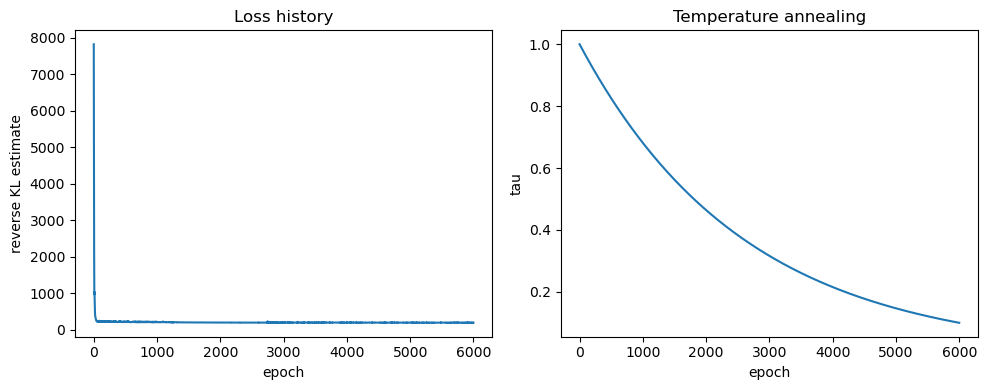


===== flow_type = affine_coupling =====

===== Variable selection summary =====
selected indices: [0, 1, 2, 3, 4]
TP: 5 FP: 0 FN: 0
precision: 1.0
recall   : 1.0

first 20 posterior inclusion probabilities:
tensor([9.9937e-01, 9.9963e-01, 9.7550e-01, 1.0000e+00, 8.8125e-01, 0.0000e+00,
        3.7500e-04, 7.5000e-04, 1.2500e-04, 2.5000e-04, 0.0000e+00, 0.0000e+00,
        1.2500e-04, 2.5000e-04, 1.2500e-04, 1.2500e-04, 1.2500e-04, 2.5000e-04,
        0.0000e+00, 6.2500e-04])

first 20 beta soft posterior means:
tensor([ 1.4553e+00, -8.2291e-01,  7.3245e-01, -1.2092e+00,  5.1736e-01,
         6.5606e-05,  2.4345e-04, -9.4457e-04, -1.9133e-04, -1.0452e-04,
        -2.9515e-05,  1.2538e-05,  8.9774e-05, -1.7182e-04,  5.3477e-05,
        -9.5511e-05,  1.6404e-04,  1.2874e-04, -1.3464e-05, -3.4987e-04])

first 20 beta hard posterior means:
tensor([ 1.5539e+00, -8.7493e-01,  8.3180e-01, -1.2448e+00,  5.8392e-01,
         0.0000e+00,  3.3778e-04, -9.4784e-04, -2.3695e-04, -1.9866e-04,
      

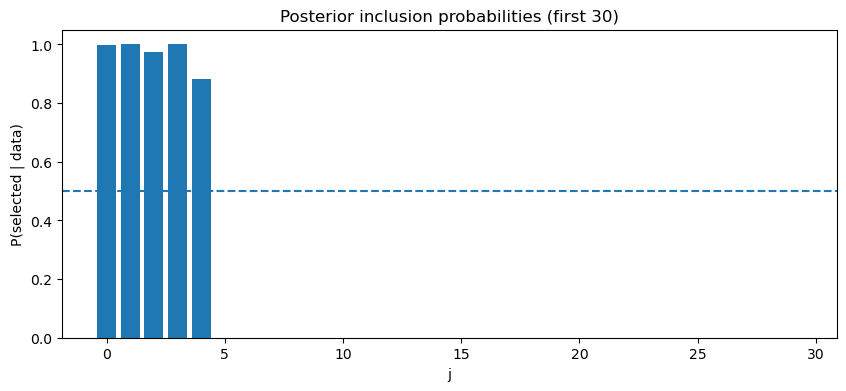

In [9]:
# =========================================================
# Full demo: single flow family
# =========================================================
n = 200
p = 100
sigma2 = 0.5

# ---------------------------------------------------------
# Simulated regression data
#   y = X beta_true + eps
#   eps ~ N(0, sigma2 I_n)
# ---------------------------------------------------------
X, y, beta_true = make_regression_data(
    n=n,
    p=p,
    sigma2=sigma2,
    device=device,
)

# ---------------------------------------------------------
# Exact Gaussian posterior for the linear-Gaussian baseline
# (only used for benchmarking)
# ---------------------------------------------------------
Sigma = torch.eye(p, device=device)
mu_post, Sigma_post = gaussian_posterior_closed_form(X, y, sigma2, Sigma)

# ---------------------------------------------------------
# Target posterior in latent space
#
# Unified latent formulation:
#   z = (s, u, t)
#   g_j = sigmoid((u_j - t) / tau)
#   beta_j = s_j * g_j
# ---------------------------------------------------------
target_dist = RelaxedSpikeSlabTarget(
    X=X,
    y=y,
    sigma2=sigma2,
    lambda_s=1.0,   # Laplace shrinkage strength
    mu_t=0.0,
    sigma_t=1.0,
    tau=1.0,        # initial tau; training will anneal it
    slab="laplace",
).to(device)

# ---------------------------------------------------------
# Choose one flow family here:
#   "planar"
#   "radial"
#   "affine_coupling"
#   "hybrid"
# ---------------------------------------------------------
flow_type = "affine_coupling"

model = build_nf(
    latent_dim=target_dist.latent_dim,
    target_dist=target_dist,
    flow_type=flow_type,
    K=8,
    hidden_units=128,
    num_hidden_layers=2,
    device=device,
)

# ---------------------------------------------------------
# Train flow posterior approximation
# ---------------------------------------------------------
losses, tau_hist = train_flow(
    model=model,
    target_dist=target_dist,
    epochs=6000,
    num_samples=1024,
    lr=1e-3,
    tau_start=1.0,
    tau_end=0.1,
    kl_anneal=False,   # keep only tau annealing unless you explicitly want KL annealing
    grad_clip=5.0,
    print_every=500,
)

plot_training(losses, tau_hist)

# ---------------------------------------------------------
# Posterior summary:
#   - soft beta
#   - hard beta
#   - posterior inclusion probability
#   - selected indices
# ---------------------------------------------------------
post_summary = posterior_summary(
    model=model,
    target_dist=target_dist,
    n_samples=8000,
    gate_threshold=0.5,       # g_j > 0.5 <=> u_j > t
    inclusion_threshold=0.5,  # final variable selection threshold on PIP
)

# ---------------------------------------------------------
# Evaluate variable selection
# ---------------------------------------------------------
print(f"\n===== flow_type = {flow_type} =====")
evaluate_against_truth(beta_true, post_summary)

# ---------------------------------------------------------
# Optional Gaussian baseline comparison
# This compares soft beta samples with the exact Gaussian posterior
# from the linear-Gaussian baseline model.
# ---------------------------------------------------------
compare_with_exact_gaussian(post_summary["beta_soft"], mu_post, Sigma_post)

# ---------------------------------------------------------
# Visualize posterior inclusion probabilities
# ---------------------------------------------------------
plot_posterior_inclusion_prob(
    post_summary["pip"],
    top_k=30,
    decision_threshold=0.5,
)


Running flow_type = planar
epoch     1 | loss = 12929.7197 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 396.4971 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 320.3771 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 274.9818 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 247.1476 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 213.9376 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 205.6202 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 192.0359 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 191.4854 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 173.8342 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 166.9835 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 164.8262 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 162.7423 | tau = 0.1000 | anneal_beta = 1.0000

===== flow_type = planar =====

===== Variable selection summary =====
selected indic

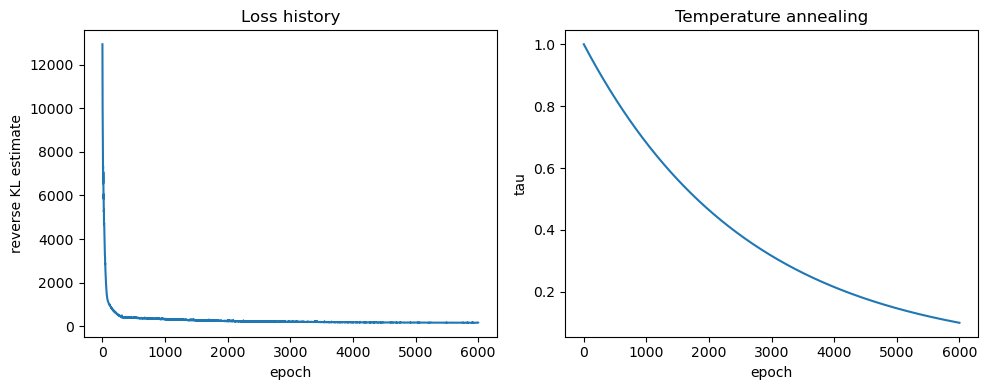

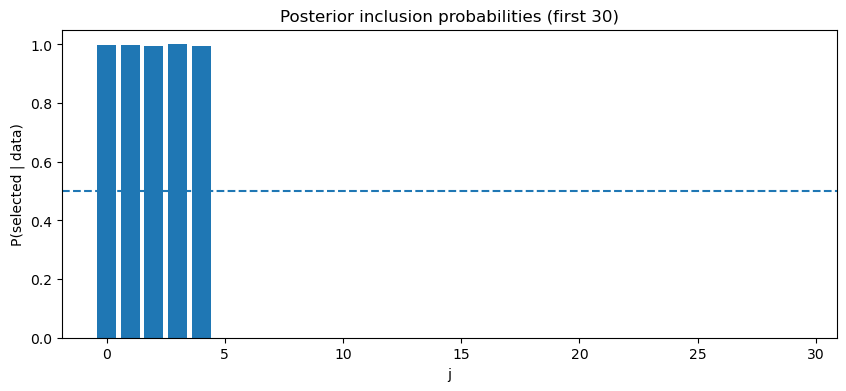


Running flow_type = radial
epoch     1 | loss = 9518.7939 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 1221.5408 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 278.3635 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 192.4740 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 168.1904 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 166.0148 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 162.6597 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 161.0631 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 160.9551 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 158.4064 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 157.2722 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 156.3419 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 155.4684 | tau = 0.1000 | anneal_beta = 1.0000

===== flow_type = radial =====

===== Variable selection summary =====
selected indic

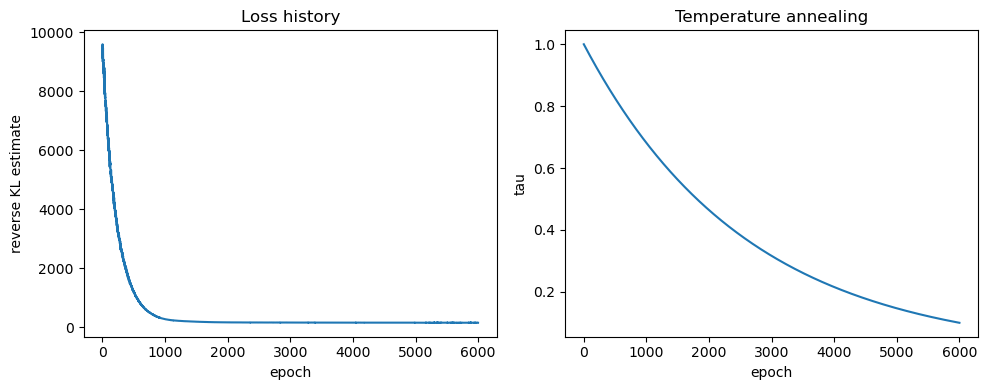

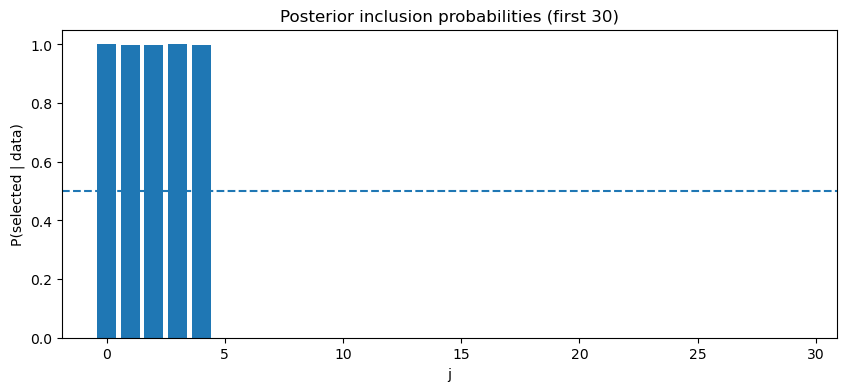


Running flow_type = affine_coupling
epoch     1 | loss = 7487.6235 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 175.7515 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 165.5121 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 167.5575 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 158.4732 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 154.7439 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 155.8886 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 153.8153 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 157.5633 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 154.2206 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 154.2863 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 154.7853 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 153.8995 | tau = 0.1000 | anneal_beta = 1.0000

===== flow_type = affine_coupling =====

===== Variable selection summary ===

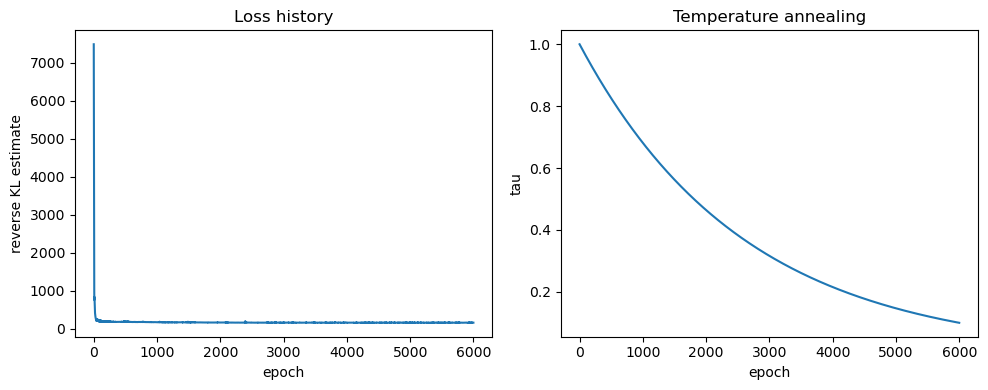

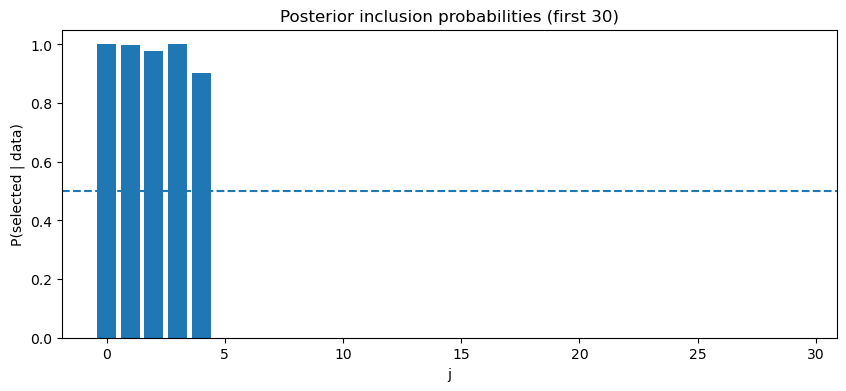


Running flow_type = hybrid
epoch     1 | loss = 19866.7637 | tau = 1.0000 | anneal_beta = 1.0000
epoch   500 | loss = 170.2436 | tau = 0.8257 | anneal_beta = 1.0000
epoch  1000 | loss = 163.6179 | tau = 0.6815 | anneal_beta = 1.0000
epoch  1500 | loss = 160.0073 | tau = 0.5625 | anneal_beta = 1.0000
epoch  2000 | loss = 157.3114 | tau = 0.4643 | anneal_beta = 1.0000
epoch  2500 | loss = 154.2560 | tau = 0.3832 | anneal_beta = 1.0000
epoch  3000 | loss = 158.0203 | tau = 0.3163 | anneal_beta = 1.0000
epoch  3500 | loss = 157.7831 | tau = 0.2611 | anneal_beta = 1.0000
epoch  4000 | loss = 152.0380 | tau = 0.2155 | anneal_beta = 1.0000
epoch  4500 | loss = 155.8351 | tau = 0.1778 | anneal_beta = 1.0000
epoch  5000 | loss = 152.6142 | tau = 0.1468 | anneal_beta = 1.0000
epoch  5500 | loss = 152.5915 | tau = 0.1212 | anneal_beta = 1.0000
epoch  6000 | loss = 151.6995 | tau = 0.1000 | anneal_beta = 1.0000

===== flow_type = hybrid =====

===== Variable selection summary =====
selected indic

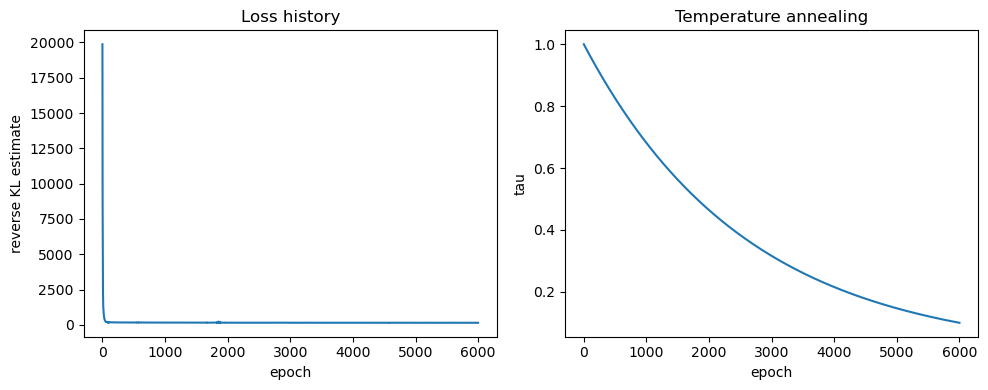

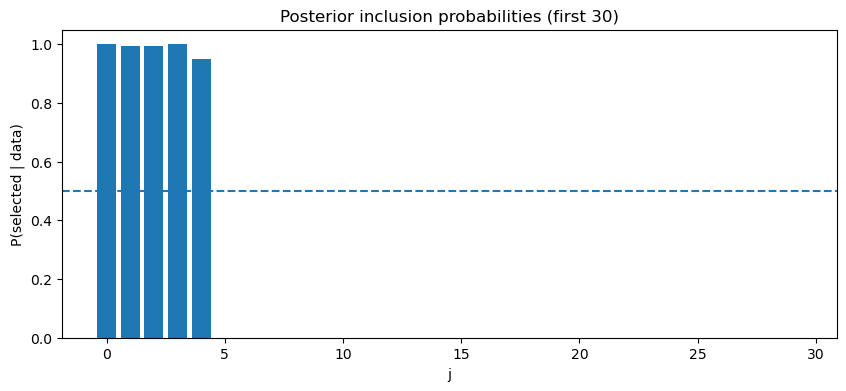

In [10]:
# =========================================================
# Full demo: compare multiple flow families
# =========================================================
n = 200
p = 100
sigma2 = 0.5

# ---------------------------------------------------------
# Simulated regression data
# ---------------------------------------------------------
X, y, beta_true = make_regression_data(
    n=n,
    p=p,
    sigma2=sigma2,
    device=device,
)

# ---------------------------------------------------------
# Exact Gaussian posterior for baseline comparison
# ---------------------------------------------------------
Sigma = torch.eye(p, device=device)
mu_post, Sigma_post = gaussian_posterior_closed_form(X, y, sigma2, Sigma)

# ---------------------------------------------------------
# Candidate flow families
# ---------------------------------------------------------
flow_types = [
    "planar",
    "radial",
    "affine_coupling",
    "hybrid",
]

all_results = {}

for flow_type in flow_types:
    print("\n" + "=" * 70)
    print(f"Running flow_type = {flow_type}")
    print("=" * 70)

    # -----------------------------------------------------
    # Rebuild target_dist for each run so that tau starts
    # fresh from tau=1.0
    # -----------------------------------------------------
    target_dist = RelaxedSpikeSlabTarget(
        X=X,
        y=y,
        sigma2=sigma2,
        lambda_s=1.0,
        mu_t=0.0,
        sigma_t=1.0,
        tau=1.0,
        slab="laplace",
    ).to(device)

    # -----------------------------------------------------
    # Build the selected flow family
    # -----------------------------------------------------
    model = build_nf(
        latent_dim=target_dist.latent_dim,
        target_dist=target_dist,
        flow_type=flow_type,
        K=8,
        hidden_units=128,
        num_hidden_layers=2,
        device=device,
    )

    # -----------------------------------------------------
    # Train
    # -----------------------------------------------------
    losses, tau_hist = train_flow(
        model=model,
        target_dist=target_dist,
        epochs=6000,
        num_samples=1024,
        lr=1e-3,
        tau_start=1.0,
        tau_end=0.1,
        kl_anneal=False,
        grad_clip=5.0,
        print_every=500,
    )

    # -----------------------------------------------------
    # Posterior summary
    # -----------------------------------------------------
    post_summary = posterior_summary(
        model=model,
        target_dist=target_dist,
        n_samples=8000,
        gate_threshold=0.5,
        inclusion_threshold=0.5,
    )

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------
    all_results[flow_type] = {
        "model": model,
        "target_dist": target_dist,
        "losses": losses,
        "tau_hist": tau_hist,
        "post_summary": post_summary,
    }

    # -----------------------------------------------------
    # Console summary
    # -----------------------------------------------------
    print(f"\n===== flow_type = {flow_type} =====")
    evaluate_against_truth(beta_true, post_summary)
    compare_with_exact_gaussian(post_summary["beta_soft"], mu_post, Sigma_post)

    # -----------------------------------------------------
    # Plots
    # -----------------------------------------------------
    plot_training(losses, tau_hist)
    plot_posterior_inclusion_prob(
        post_summary["pip"],
        top_k=30,
        decision_threshold=0.5,
    )